# Pipeline Preprocessing Citra Daun Anggur
**Task 1 — Feature Extraction**

| # | Tahap | Teknik |
|---|-------|--------|
| 1 | Segmentasi Latar Belakang | HSV Masking |
| 2 | Pemerataan Pencahayaan | CLAHE |
| 3 | Penstabilan Rasio Geometri | Zero-Padding & Resize |
| 4 | Normalisasi Skala | Min-Max (÷ 255) |
| 5 | Augmentasi Geometris | Rotasi + Flip |

## 0. Import Library & Konfigurasi Path

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# ── Konfigurasi ──────────────────────────────────────────────
DATASET_DIR   = Path("Dataset")
OUTPUT_DIR    = Path("Preprocessed")
TARGET_SIZE1   = 32
TARGET_SIZE2   = 64
TARGET_SIZE3   = 128
RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

# Daftar kelas (sub-folder)
CLASS_NAMES = sorted([
    d for d in os.listdir(DATASET_DIR)
    if (DATASET_DIR / d).is_dir()
])
print("Kelas ditemukan:", CLASS_NAMES)
print("Jumlah kelas   :", len(CLASS_NAMES))

Kelas ditemukan: ['Grape Esca (Black_Measles)', 'Grape Leaf blight (Isariopsis_Leaf_Spot)', 'grape leaf Healthy', 'grape leaf black rot']
Jumlah kelas   : 4


## 1. Segmentasi Latar Belakang (HSV Masking)
Mengisolasi objek daun dan menghitamkan area latar belakang menggunakan ruang warna HSV.  
**Tujuan:** Mencegah model salah mengenali warna tanah, pot, atau bayangan sebagai bercak penyakit.

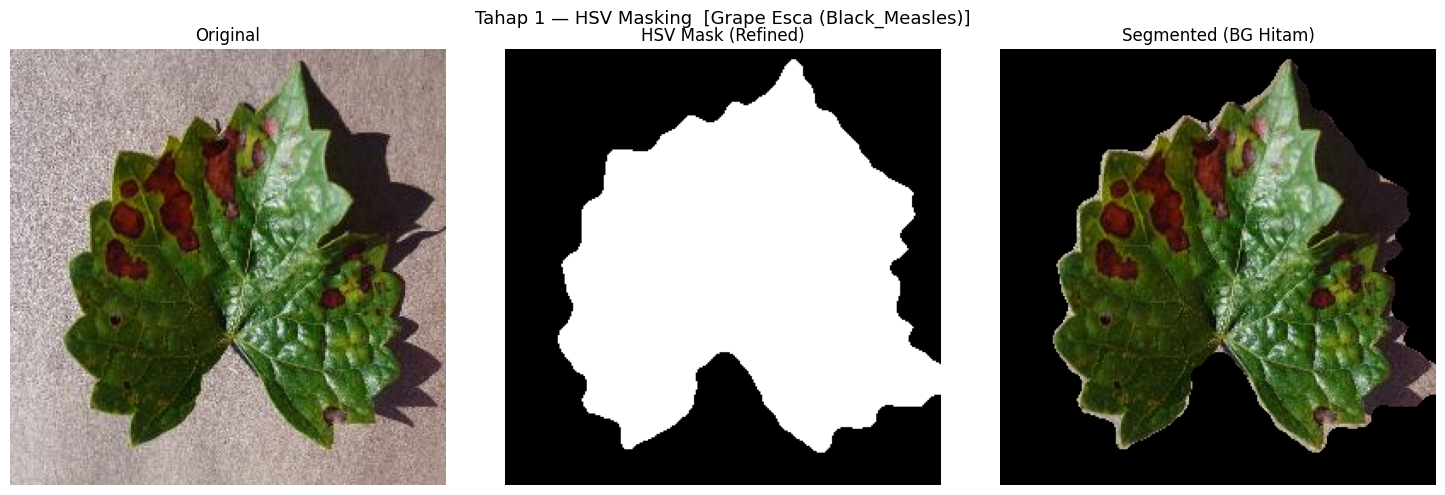

In [2]:
def segment_leaf_hsv(image_bgr, min_area_ratio=0.01):
    """
    Segmentasi daun dengan HSV + pembersihan komponen.
    - Menggabungkan rentang warna daun (hijau/kuning/coklat/merah)
    - Menolak piksel low-saturation (background kusam)
    - Menyisakan komponen terbesar agar background tidak ikut
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Rentang warna daun (lebih ketat)
    lower_green = np.array([20, 35, 25])
    upper_green = np.array([95, 255, 255])

    lower_yellow = np.array([15, 40, 35])
    upper_yellow = np.array([35, 255, 255])

    lower_brown = np.array([5, 50, 20])
    upper_brown = np.array([20, 255, 220])

    lower_red1 = np.array([0, 50, 30])
    upper_red1 = np.array([12, 255, 255])
    lower_red2 = np.array([160, 50, 30])
    upper_red2 = np.array([180, 255, 255])

    # Mask warna
    mask_color  = cv2.inRange(hsv, lower_green, upper_green)
    mask_color |= cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask_color |= cv2.inRange(hsv, lower_brown, upper_brown)
    mask_color |= cv2.inRange(hsv, lower_red1, upper_red1)
    mask_color |= cv2.inRange(hsv, lower_red2, upper_red2)

    # Tolak background abu/gelap (S dan V terlalu rendah)
    mask_sv = cv2.inRange(hsv, np.array([0, 35, 25]), np.array([180, 255, 255]))
    mask = cv2.bitwise_and(mask_color, mask_sv)

    # Morphological cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Keep komponen terbesar (leaf utama)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)

    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]  # abaikan background index 0
        largest_idx = 1 + np.argmax(areas)
        largest_area = stats[largest_idx, cv2.CC_STAT_AREA]

        h, w = mask.shape[:2]
        min_area = int(min_area_ratio * h * w)

        if largest_area >= min_area:
            refined[labels == largest_idx] = 255
        else:
            refined = mask.copy()
    else:
        refined = mask.copy()

    # Haluskan tepi akhir
    refined = cv2.medianBlur(refined, 5)
    result = cv2.bitwise_and(image_bgr, image_bgr, mask=refined)
    return result, refined


# ── Demo visual ──────────────────────────────────────────────
sample_class = CLASS_NAMES[0]
sample_path  = DATASET_DIR / sample_class
sample_files = sorted([
    f for f in os.listdir(sample_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
])
img = cv2.imread(str(sample_path / sample_files[0]))

seg, msk = segment_leaf_hsv(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(msk, cmap="gray")
axes[1].set_title("HSV Mask (Refined)")
axes[2].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
axes[2].set_title("Segmented (BG Hitam)")
for ax in axes: ax.axis("off")
plt.suptitle(f"Tahap 1 — HSV Masking  [{sample_class}]", fontsize=13)
plt.tight_layout()
plt.show()

## 2. Pemerataan Pencahayaan (CLAHE)
Meratakan kontras pencahayaan secara lokal (per blok piksel) pada kanal L di ruang warna LAB.  
**Tujuan:** Menghilangkan efek silau matahari & bayangan tajam agar detail penyakit tetap terekstrak.

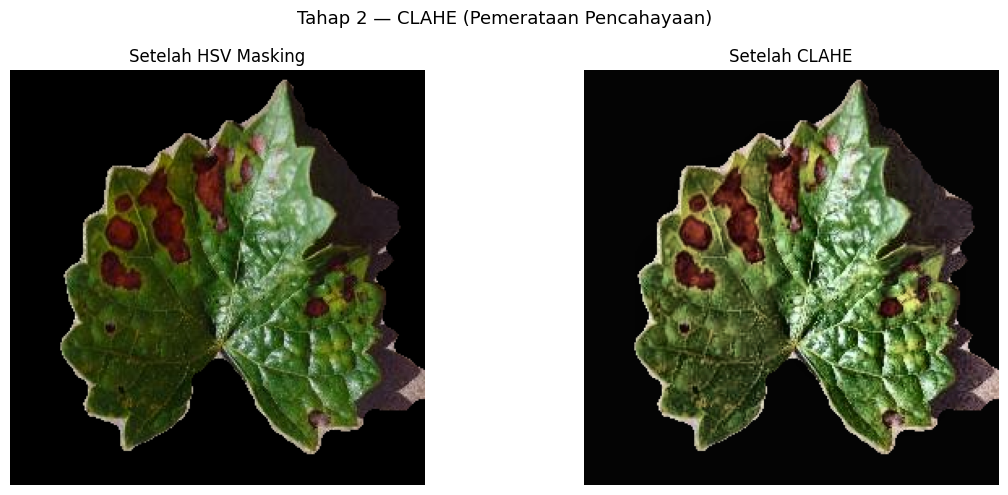

In [3]:
def apply_clahe(image_bgr, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Menerapkan CLAHE pada kanal L (Lightness) di ruang warna LAB.
    Kontras diperbaiki secara lokal tanpa mengubah pigmen warna asli.
    """
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l_channel)

    lab_eq = cv2.merge([l_eq, a_channel, b_channel])
    result = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    return result


# ── Demo visual ──────────────────────────────────────────────
clahe_result = apply_clahe(seg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
axes[0].set_title("Setelah HSV Masking")
axes[1].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[1].set_title("Setelah CLAHE")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 2 — CLAHE (Pemerataan Pencahayaan)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Penstabilan Rasio Geometri (Zero-Padding & Resize)
Menambahkan bingkai hitam (padding) hingga gambar menjadi persegi sempurna, lalu diperkecil ke resolusi target.  
**Tujuan:** Memenuhi syarat input model tanpa mendistorsi anatomi daun / bentuk penyakit.

In [4]:
def zero_pad_and_resize(image_bgr, target_size=224):
    """
    1. Zero-padding → jadikan persegi (sisi = max(h, w))
    2. Resize       → target_size × target_size
    Aspect ratio asli dipertahankan; area tambahan diisi hitam.
    """
    h, w = image_bgr.shape[:2]
    max_side = max(h, w)

    # Buat canvas hitam persegi
    canvas = np.zeros((max_side, max_side, 3), dtype=np.uint8)

    # Letakkan gambar di tengah canvas
    y_offset = (max_side - h) // 2
    x_offset = (max_side - w) // 2
    canvas[y_offset:y_offset + h, x_offset:x_offset + w] = image_bgr

    # Resize ke target
    resized = cv2.resize(canvas, (target_size, target_size),
                         interpolation=cv2.INTER_AREA)
    return resized

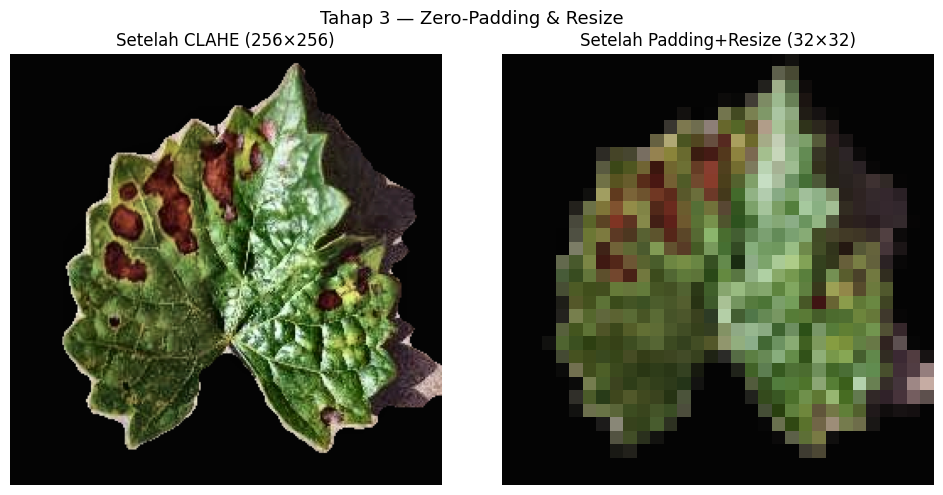

In [5]:

# ── Demo visual ──────────────────────────────────────────────
padded = zero_pad_and_resize(clahe_result, TARGET_SIZE1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Setelah CLAHE ({clahe_result.shape[1]}×{clahe_result.shape[0]})")
axes[1].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Padding+Resize ({TARGET_SIZE1}×{TARGET_SIZE1})")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 3 — Zero-Padding & Resize", fontsize=13)
plt.tight_layout()
plt.show()

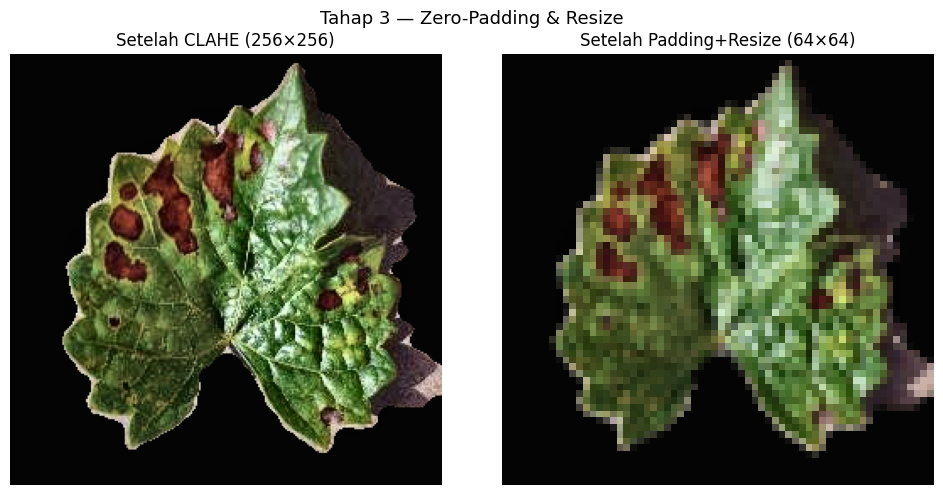

In [6]:

# ── Demo visual ──────────────────────────────────────────────
padded = zero_pad_and_resize(clahe_result, TARGET_SIZE2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Setelah CLAHE ({clahe_result.shape[1]}×{clahe_result.shape[0]})")
axes[1].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Padding+Resize ({TARGET_SIZE2}×{TARGET_SIZE2})")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 3 — Zero-Padding & Resize", fontsize=13)
plt.tight_layout()
plt.show()

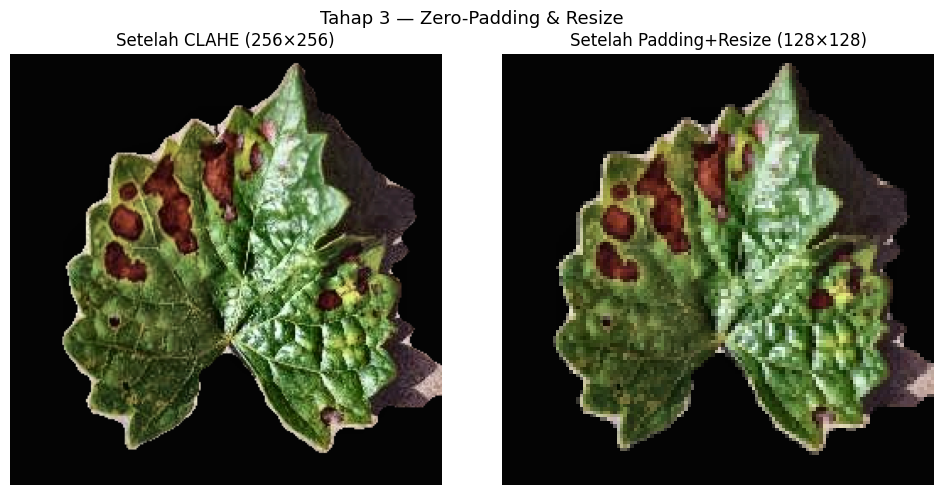

In [7]:

# ── Demo visual ──────────────────────────────────────────────
padded = zero_pad_and_resize(clahe_result, TARGET_SIZE3)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(clahe_result, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Setelah CLAHE ({clahe_result.shape[1]}×{clahe_result.shape[0]})")
axes[1].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Padding+Resize ({TARGET_SIZE3}×{TARGET_SIZE3})")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 3 — Zero-Padding & Resize", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Normalisasi Skala (Min-Max Normalization)
Membagi seluruh nilai matriks piksel dengan 255 sehingga rentang baru menjadi **[0, 1]**.  
**Tujuan:** Meringankan beban komputasi, menstabilkan kalkulasi matematis, dan mencegah OOM.

Tipe data  : float32
Nilai min  : 0.0000
Nilai max  : 1.0000
Shape      : (128, 128, 3)


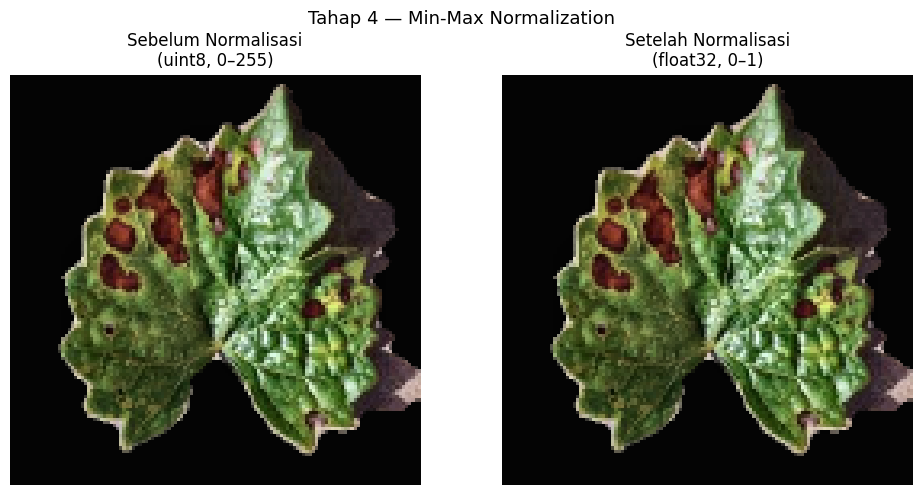

In [8]:
def normalize_minmax(image_bgr):
    """
    Min-Max Normalization: pixel / 255.0
    Output bertipe float32 dengan rentang [0, 1].
    """
    return image_bgr.astype(np.float32) / 255.0


# ── Demo visual ──────────────────────────────────────────────
normed = normalize_minmax(padded)

print(f"Tipe data  : {normed.dtype}")
print(f"Nilai min  : {normed.min():.4f}")
print(f"Nilai max  : {normed.max():.4f}")
print(f"Shape      : {normed.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Sebelum Normalisasi\n(uint8, 0–255)")
axes[1].imshow(cv2.cvtColor(normed, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Setelah Normalisasi\n(float32, 0–1)")
for ax in axes: ax.axis("off")
plt.suptitle("Tahap 4 — Min-Max Normalization", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Augmentasi Geometris (Data Augmentation)
Memutar dan membalikkan (flip horizontal/vertikal) gambar secara acak.  
**Tujuan:** Mensimulasikan kondisi foto dunia nyata agar model benar-benar belajar karakteristik penyakit, bukan menghafal koordinat piksel.

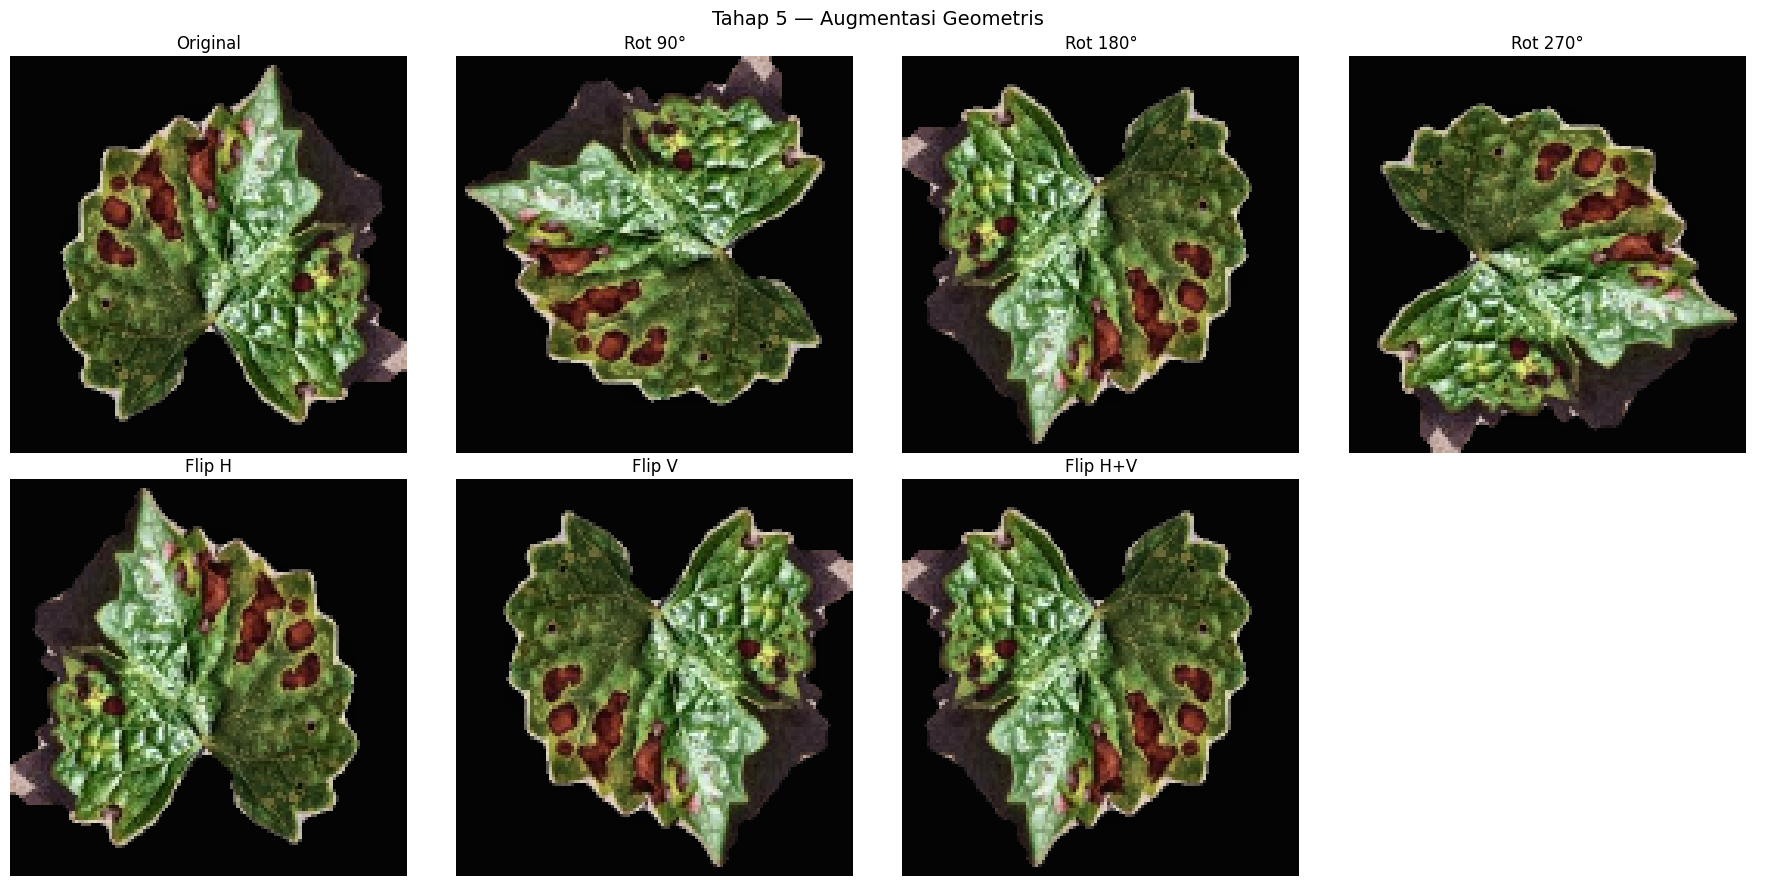

In [9]:
def augment_image(image):
    """
    Augmentasi geometris acak:
      - Rotasi 90°/180°/270°
      - Flip horizontal
      - Flip vertikal
      - Flip horizontal + vertikal
    Mengembalikan list gambar hasil augmentasi (TIDAK termasuk gambar asli).
    """
    augmented = []

    # Rotasi 90°, 180°, 270°
    for k in [1, 2, 3]:
        augmented.append(np.rot90(image, k=k).copy())

    # Flip horizontal
    augmented.append(np.flip(image, axis=1).copy())

    # Flip vertikal
    augmented.append(np.flip(image, axis=0).copy())

    # Flip horizontal + vertikal (setara rotasi 180° + flip)
    augmented.append(np.flip(image, axis=(0, 1)).copy())

    return augmented


# ── Demo visual ──────────────────────────────────────────────
aug_imgs = augment_image(normed)
labels   = ["Rot 90°", "Rot 180°", "Rot 270°",
            "Flip H", "Flip V", "Flip H+V"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
# Gambar asli di posisi pertama
axes[0, 0].imshow(cv2.cvtColor(normed, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for idx, (aug, lbl) in enumerate(zip(aug_imgs, labels)):
    row, col = divmod(idx + 1, 4)
    axes[row, col].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    axes[row, col].set_title(lbl)
    axes[row, col].axis("off")

# Matikan axis kosong
axes[1, 3].axis("off")

plt.suptitle("Tahap 5 — Augmentasi Geometris", fontsize=14)
plt.tight_layout()
plt.show()

## Ringkasan Visual — 1 Gambar Melewati Semua Tahap Preprocessing
Menampilkan hasil **setiap step** secara berurutan pada satu gambar sampel.

In [10]:
# ── Ambil 1 gambar sampel ─────────────────────────────────────
sample_class = CLASS_NAMES[0]
sample_dir   = DATASET_DIR / sample_class
sample_file  = sorted([f for f in os.listdir(sample_dir)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])[0]
original = cv2.imread(str(sample_dir / sample_file))

# ── Jalankan tiap tahap satu per satu ────────────────────────
step1_hsv, mask       = segment_leaf_hsv(original)
step2_clahe           = apply_clahe(step1_hsv)
step3_padresize       = zero_pad_and_resize(step2_clahe, TARGET_SIZE)
step4_norm            = normalize_minmax(step3_padresize)
step5_aug_list        = augment_image(step4_norm)
step5_sample          = step5_aug_list[0]   # ambil rotasi 90° sebagai contoh

# ── Siapkan data untuk plot ───────────────────────────────────
stages = [
    ("0 — Original",                   original,       True),
    ("1 — HSV Masking",                step1_hsv,      True),
    ("2 — CLAHE",                      step2_clahe,    True),
    ("3 — Zero-Pad & Resize (224×224)",step3_padresize,True),
    ("4 — Normalisasi [0,1]",          step4_norm,     False),
    ("5 — Augmentasi (Rot 90°)",       step5_sample,   False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx, (title, img, is_uint8) in enumerate(stages):
    row, col = divmod(idx, 3)
    ax = axes[row][col]

    if is_uint8:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        # float32 [0,1] — clip untuk keamanan tampilan
        display = np.clip(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0, 1)
        ax.imshow(display)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

    # Tambahkan info shape & dtype di bawah judul
    h, w = img.shape[:2]
    dtype = img.dtype
    info = f"{w}×{h}  |  {dtype}"
    if not is_uint8:
        info += f"  |  min={img.min():.2f}  max={img.max():.2f}"
    ax.text(0.5, -0.04, info, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='gray')

plt.suptitle(f"Contoh Hasil Setiap Tahap Preprocessing\nSampel: {sample_class}/{sample_file}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'TARGET_SIZE' is not defined